In [1]:
import os
import warnings
import boto3
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin

#### Functions

In [2]:
# feature engineer
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Custom sklearn transformer for credit risk feature engineering.
    - Engineers int_age from dob: age is a known predictor of creditworthiness.
    - Engineers flt_payment_to_income: payment-to-income ratio is a standard
      credit risk feature that measures borrower capacity.
    Note: no columns are dropped here. Column exclusion is handled in 04_model
    to keep preprocessing fast.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()
        # engineer age from dob
        if 'dob' in df.columns:
            df['dob'] = pd.to_datetime(df['dob'])
            df['int_age'] = ((pd.Timestamp.now() - df['dob']).dt.days / 365.25).astype(int)
        # engineer payment to income ratio
        if 'loan_amount' in df.columns and 'stated_income' in df.columns:
            df['flt_payment_to_income'] = df['loan_amount'] / df['stated_income'].replace(0, np.nan)
        return df

In [3]:
# plot missing before and after preprocessing
def plot_missing_before_after(df_before, df_after, str_filename='output/missing_before_after.png'):
    ser_before = df_before.isnull().mean()
    ser_after = df_after.isnull().mean()
    # only show columns that had missing values before
    ser_before = ser_before[ser_before > 0].sort_values(ascending=True)
    if len(ser_before) == 0:
        print('No missing values found before preprocessing.')
        return
    ser_after = ser_after.reindex(ser_before.index).fillna(0)
    # plot
    list_cols = ser_before.index.tolist()
    arr_y = np.arange(len(list_cols))
    flt_bar_height = 0.35
    fig, ax = plt.subplots(figsize=(10, max(5, len(list_cols) * 0.5)))
    ax.barh(arr_y + flt_bar_height / 2, ser_before.values, flt_bar_height, label='Before', color='salmon', edgecolor='black')
    ax.barh(arr_y - flt_bar_height / 2, ser_after.values, flt_bar_height, label='After', color='steelblue', edgecolor='black')
    ax.set_yticks(arr_y)
    ax.set_yticklabels(list_cols)
    ax.set_title('Proportion Missing Before and After Preprocessing', fontsize=16)
    ax.set_xlabel('Proportion Missing', fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.savefig(str_filename, dpi=300)
    plt.show()

#### Constants

In [4]:
# bucket
str_bucket = os.getcwd().split('/')[4].replace('_', '-')
print(f'Bucket: {str_bucket}')

# step
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')

# s3 input path
str_s3_input = f's3://{str_bucket}/02_data_split'
print(f'S3 Input: {str_s3_input}')

# target
str_target = 'default_12m'
print(f'Target: {str_target}')

# output directory
os.makedirs('output', exist_ok=True)

Bucket: credit-risk-claude
Step: 03_preprocessing
S3 Input: s3://credit-risk-claude/02_data_split
Target: default_12m


#### Read Data

In [5]:
# read data
df_train = pd.read_parquet(f'{str_s3_input}/df_train.parquet')
df_valid = pd.read_parquet(f'{str_s3_input}/df_valid.parquet')
df_test = pd.read_parquet(f'{str_s3_input}/df_test.parquet')

# print shapes
for str_name, df_split in [('Train', df_train), ('Validation', df_valid), ('Test', df_test)]:
    print(f'{str_name}: {df_split.shape}')

Train: (17715, 20)
Validation: (3796, 20)
Test: (3797, 20)


#### Feature Engineering

The first step derives new features and identifies column types. The `FeatureEngineer` transformer creates age from date of birth and a payment-to-income ratio. We run it here to determine which columns are numeric vs. categorical for the next pipeline step. Column dropping (leaky variables, IDs, etc.) is deferred to the modeling notebook where feature selection decisions are made.

In [6]:
# apply feature engineering to determine column names
feature_engineer = FeatureEngineer()
df_train_fe = feature_engineer.transform(df_train)

# separate target
list_feature_cols = [col for col in df_train_fe.columns if col != str_target]

# identify numeric and categorical columns
list_numeric_cols = df_train_fe[list_feature_cols].select_dtypes(include=[np.number]).columns.tolist()
list_categorical_cols = df_train_fe[list_feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric features ({len(list_numeric_cols)}): {list_numeric_cols}')
print(f'Categorical features ({len(list_categorical_cols)}): {list_categorical_cols}')

Numeric features (17): ['loan_id', 'loan_amount', 'term_months', 'employment_length_years', 'stated_income', 'has_prior_loans_with_us', 'bureau_score', 'open_trades', 'delinq_12m', 'utilization', 'inquiries_6m', 'public_records', 'charged_off_amount', 'paid_interest_amount', 'apr', 'int_age', 'flt_payment_to_income']
Categorical features (2): ['channel', 'state']


#### Numeric Preprocessing

Numeric features are imputed using the **median**. Median is preferred over mean because credit risk data often has skewed distributions (e.g., income, loan amounts), and the median is robust to outliers. No scaling is applied because XGBoost is a tree-based algorithm that splits on thresholds, making it invariant to monotonic transformations of the features.

In [7]:
# numeric transformer
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
])

#### Categorical Preprocessing

Categorical features are first imputed with the constant string "missing", treating missingness as its own category. This is appropriate for credit risk because the absence of data can itself be informative (e.g., a missing employment length may indicate informal employment). Then **ordinal encoding** is applied. Ordinal encoding is preferred over one-hot encoding for XGBoost because it avoids creating high-dimensional sparse features and XGBoost can learn effective splits on ordinal values. Unknown categories encountered at inference time are encoded as -1.

In [8]:
# categorical transformer
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

#### Assemble Pipeline

The full pipeline chains the `FeatureEngineer` with a `ColumnTransformer` that routes numeric and categorical features to their respective preprocessing steps. This ensures the entire preprocessing workflow is encapsulated in a single serializable object that can be saved and reused in the API for inference.

In [9]:
# assemble full pipeline
column_transformer = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, list_numeric_cols),
        ('cat', categorical_transformer, list_categorical_cols),
    ],
)

pipeline = Pipeline(steps=[
    ('feature_engineer', FeatureEngineer()),
    ('column_transformer', column_transformer),
])

print('Pipeline defined successfully')
print(pipeline)

Pipeline defined successfully
Pipeline(steps=[('feature_engineer', FeatureEngineer()),
                ('column_transformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['loan_id', 'loan_amount',
                                                   'term_months',
                                                   'employment_length_years',
                                                   'stated_income',
                                                   'has_prior_loans_with_us',
                                                   'bureau_score',
                                                   'open_trades', 'delinq_12m',
                                                   'utilization',
                                                   'inq

#### Fit and Transform

The pipeline is fit on the training data only. This is critical to prevent data leakage. If we fit on validation or test data, the imputed medians and encoder mappings would contain information from data the model should never see during training. After fitting on train, we transform all three splits using the same learned parameters.

#### Fit

In [10]:
warnings.filterwarnings('ignore')

# fit on training data ONLY
pipeline.fit(df_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineer', ...), ('column_transformer', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

#### Save

In [11]:
# save pipeline immediately after fitting
joblib.dump(pipeline, 'output/preprocessing_pipeline.joblib')
print('Pipeline saved to output/preprocessing_pipeline.joblib')

Pipeline saved to output/preprocessing_pipeline.joblib


#### Learned Parameters

Inspecting the fitted pipeline's learned parameters increases transparency and auditability. This allows stakeholders to answer questions like "what value was imputed for bureau_score?" without needing to load the serialized pipeline object.

In [ ]:
# numeric imputer: learned median values
numeric_imputer = pipeline.named_steps['column_transformer'].named_transformers_['num'].named_steps['imputer']
df_medians = pd.DataFrame({
    'feature': list_numeric_cols,
    'median': numeric_imputer.statistics_,
}).sort_values('feature').reset_index(drop=True)
print('Numeric Imputation (median):')
display(df_medians)

# categorical encoder: learned category mappings
cat_pipeline = pipeline.named_steps['column_transformer'].named_transformers_['cat']
encoder = cat_pipeline.named_steps['encoder']
print('\nCategorical Encoding (ordinal):')
for str_col, arr_categories in zip(list_categorical_cols, encoder.categories_):
    df_mapping = pd.DataFrame({
        'category': arr_categories,
        'encoded_value': range(len(arr_categories)),
    })
    print(f'\n{str_col}:')
    display(df_mapping)

#### Transform

In [12]:
# transform all splits
list_col_names = list_numeric_cols + list_categorical_cols

arr_train = pipeline.transform(df_train)
arr_valid = pipeline.transform(df_valid)
arr_test = pipeline.transform(df_test)

# reconstruct DataFrames
df_train_clean = pd.DataFrame(arr_train, columns=list_col_names)
df_train_clean[str_target] = df_train[str_target].values

df_valid_clean = pd.DataFrame(arr_valid, columns=list_col_names)
df_valid_clean[str_target] = df_valid[str_target].values

df_test_clean = pd.DataFrame(arr_test, columns=list_col_names)
df_test_clean[str_target] = df_test[str_target].values

warnings.filterwarnings('default')

# print shapes
for str_name, df_split in [('Train', df_train_clean), ('Validation', df_valid_clean), ('Test', df_test_clean)]:
    print(f'{str_name}: {df_split.shape}')

df_train_clean.head()

Train: (17715, 20)
Validation: (3796, 20)
Test: (3797, 20)


,loan_id,loan_amount,term_months,employment_length_years,stated_income,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,charged_off_amount,paid_interest_amount,apr,int_age,flt_payment_to_income,channel,state,default_12m
0,17794.0,5410.0,18.0,8.39,2951.0,0.0,604.0,1.0,1.0,0.47,3.0,1.0,0.0,1715.89,0.221,34.0,1.833277,4.0,21.0,0
1,13499.0,10000.0,12.0,4.52,5410.0,0.0,600.0,2.0,0.0,0.46,3.0,0.0,0.0,1672.59,0.209,59.0,1.848429,5.0,4.0,0
2,24476.0,8480.0,12.0,3.81,3244.0,0.0,557.0,2.0,0.0,0.48,5.0,2.0,0.0,2379.19,0.303,41.0,2.614057,5.0,18.0,0
3,5438.0,3510.0,18.0,9.82,5147.0,1.0,651.0,3.0,0.0,0.18,1.0,0.0,0.0,706.84,0.150,44.0,0.681951,5.0,6.0,0
4,11493.0,6630.0,24.0,4.99,6389.0,1.0,611.0,1.0,0.0,0.41,3.0,1.0,0.0,2160.10,0.159,34.0,1.037721,5.0,18.0,0


#### Missing Values Before and After

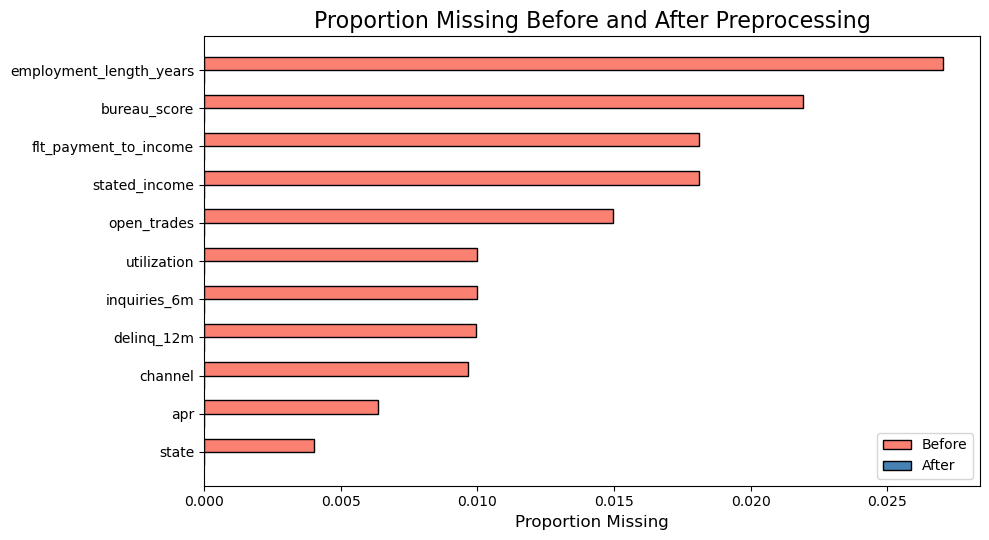

In [13]:
plot_missing_before_after(df_train_fe, df_train_clean)

#### Save

In [14]:
# save clean data to s3 for use in 04_model
for str_name, df_split in [('df_train_clean', df_train_clean), ('df_valid_clean', df_valid_clean), ('df_test_clean', df_test_clean)]:
    str_s3_output = f's3://{str_bucket}/{str_step}/{str_name}.parquet'
    df_split.to_parquet(str_s3_output, index=False)
    print(f'{str_name} saved to {str_s3_output}')

df_train_clean saved to s3://credit-risk-claude/03_preprocessing/df_train_clean.parquet
df_valid_clean saved to s3://credit-risk-claude/03_preprocessing/df_valid_clean.parquet
df_test_clean saved to s3://credit-risk-claude/03_preprocessing/df_test_clean.parquet
